In [2]:
!pip3 install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 1.4 MB/s  0:00:061.4 MB/s eta 0:00:01:02
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.4 MB/s  0:00:021.3 MB/s eta 0:00:01:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 1.6 MB/s  0:00:02m 1.6 MB/s eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
bird_path = "filtered_new_bird_data.csv"
weather_path = "monthly_weather.csv"
bird = pd.read_csv(bird_path)
weather = pd.read_csv(weather_path)
print(bird.head())
print(weather.head())


Matplotlib is building the font cache; this may take a moment.


  taxonomic_order category          common_name     scientific_name  \
0           32288  species     Asian Rosy-Finch  Leucosticte arctoa   
1           21391  species  Azure-winged Magpie    Cyanopica cyanus   
2           21391  species  Azure-winged Magpie    Cyanopica cyanus   
3           21391  species  Azure-winged Magpie    Cyanopica cyanus   
4           21391  species  Azure-winged Magpie    Cyanopica cyanus   

   observation_count country    state  county  county_code  \
0               80.0   China  Beijing     NaN          NaN   
1               15.0   China  Beijing     NaN          NaN   
2               10.0   China  Beijing     NaN          NaN   
3               70.0   China  Beijing     NaN          NaN   
4                4.0   China  Beijing     NaN          NaN   

                          locality  ...    year  month   day weekday  \
0                         Lingshan  ...  2015.0    1.0   5.0     0.0   
1                       NE Beijing  ...  2015.0    1.0  

/var/folders/xf/dq8k4dv10bl_p4pcqkqk3y580000gp/T/ipykernel_43640/2914417958.py:5: DtypeWarning: Columns (0: taxonomic_order) have mixed types. Specify dtype option on import or set low_memory=False.
  bird = pd.read_csv(bird_path)


In [4]:
print(bird.columns)
print(weather.columns)

Index(['taxonomic_order', 'category', 'common_name', 'scientific_name',
       'observation_count', 'country', 'state', 'county', 'county_code',
       'locality', 'latitude', 'longitude', 'observation_date',
       'time_observations_started', 'observation_type', 'protocol_name',
       'duration_minutes', 'effort_distance_km', 'number_observers',
       'all_species_reported', 'reason', 'presence', 'year', 'month', 'day',
       'weekday', 'dayofyear', 'hour', 'is_weekend', 'migration_season',
       'morning_peak', 'evening_peak'],
      dtype='str')
Index(['year', 'month', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'pres',
       'GDD', 'extreme_high', 'extreme_low', 'rain_day', 'strong_wind'],
      dtype='str')


In [7]:
#统一颗粒度
bird["observation_date"] = pd.to_datetime(bird["observation_date"])

bird["year_month"] = bird["observation_date"].dt.to_period("M").dt.to_timestamp()

weather["year_month"] = pd.to_datetime(
    weather["year"].astype(str) + "-" + weather["month"].astype(str) + "-01"
)

In [8]:
#每月总count
bird_monthly = (
    bird.groupby("year_month")["observation_count"]
    .sum()
    .reset_index()
)

bird_monthly.rename(columns={"observation_count": "monthly_observation_count"}, inplace=True)

bird_monthly.head()

,year_month,monthly_observation_count
0,2015-01-01,3692.0
1,2015-02-01,1914.0
2,2015-03-01,8425.0
3,2015-04-01,8714.0
4,2015-05-01,14529.0


In [9]:
#只保留一些环境数据
weather_monthly = weather[["year_month", "tavg", "tmin", "tmax"]].copy()

weather_monthly.head()

,year_month,tavg,tmin,tmax
0,2017-01-01,-2.253846,-7.842308,3.350000
1,2017-02-01,2.466667,-4.225000,8.858333
2,2017-03-01,9.204348,1.895652,15.439130
3,2017-04-01,16.946429,8.757143,23.685714
4,2017-05-01,23.791667,15.345833,30.525000


In [10]:
#合并数据
merged = pd.merge(
    bird_monthly,
    weather_monthly,
    on="year_month",
    how="inner"
)

merged.head()

,year_month,monthly_observation_count,tavg,tmin,tmax
0,2017-01-01,9924.0,-2.253846,-7.842308,3.350000
1,2017-02-01,7563.0,2.466667,-4.225000,8.858333
2,2017-03-01,23703.0,9.204348,1.895652,15.439130
3,2017-04-01,16715.0,16.946429,8.757143,23.685714
4,2017-05-01,21390.0,23.791667,15.345833,30.525000


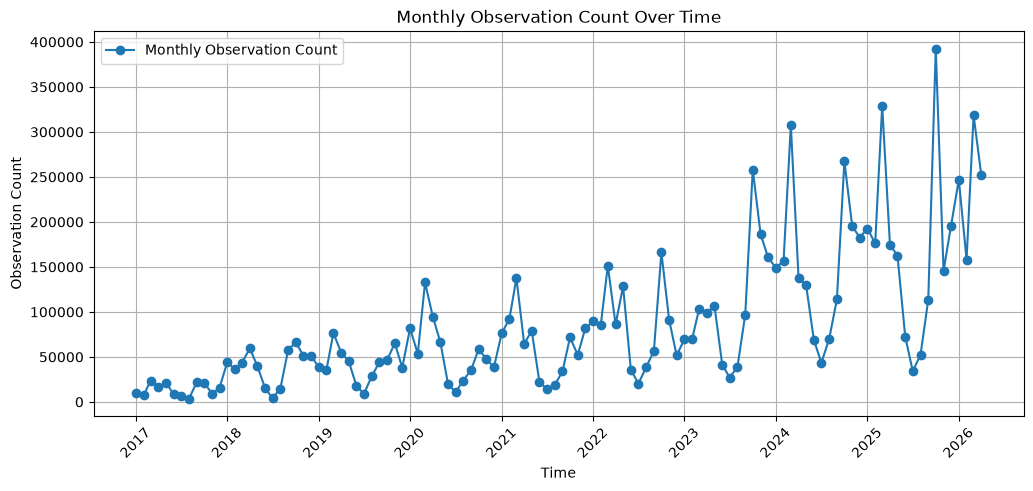

In [12]:
#figure1:observation count change by month
plt.figure(figsize=(12, 5))

plt.plot(
    merged["year_month"],
    merged["monthly_observation_count"],
    marker="o",
    label="Monthly Observation Count"
)

plt.xlabel("Time")
plt.ylabel("Observation Count")
plt.title("Monthly Observation Count Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

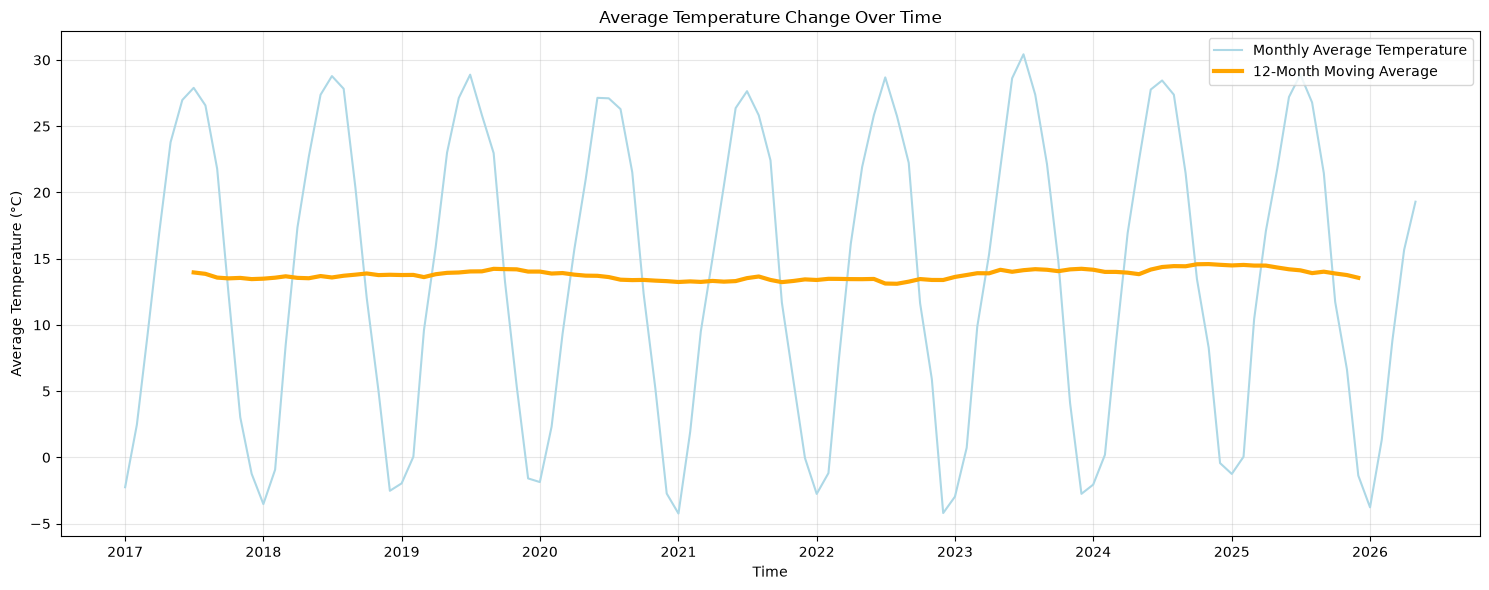

In [60]:
#figure2: temperature change by month
weather_monthly = weather.sort_values("year_month").copy()

weather_monthly["temp_12month"] = (
    weather_monthly["tavg"]
    .rolling(window=12, center=True)
    .mean()
)

plt.figure(figsize=(15,6))

# Month Temperature 
plt.plot(
    weather_monthly["year_month"],
    weather_monthly["tavg"],
    color="lightblue",
    linewidth=1.5,
    alpha=1,
    label="Monthly Average Temperature"
)

# Long-term Trend
plt.plot(
    weather_monthly["year_month"],
    weather_monthly["temp_12month"],
    color="orange",
    linewidth=3,
    label="12-Month Moving Average"
)

plt.xlabel("Time")
plt.ylabel("Average Temperature (°C)")

plt.title("Average Temperature Change Over Time")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [46]:
#standardize
merged["obs_scaled"] = (
    merged["monthly_observation_count"] -
    merged["monthly_observation_count"].mean()
) / merged["monthly_observation_count"].std()

merged["temp_scaled"] = (
    merged["tavg"] -
    merged["tavg"].mean()
) / merged["tavg"].std()

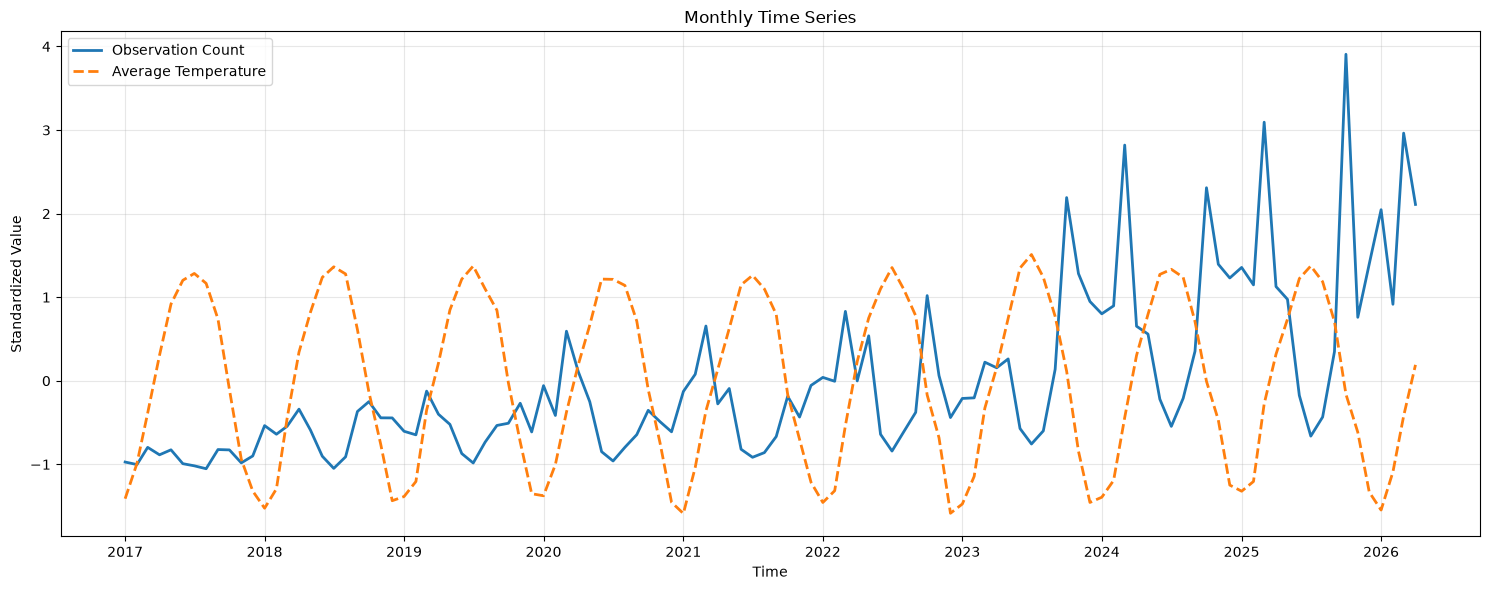

In [34]:
#figure3: monthly overlapping figure of observation count and average temperature 
plt.figure(figsize=(15,6))

plt.plot(
    merged["year_month"],
    merged["obs_scaled"],
    linewidth=2,
    label="Observation Count"
)

plt.plot(
    merged["year_month"],
    merged["temp_scaled"],
    linewidth=2,
    linestyle="--",
    label="Average Temperature"
)

plt.xlabel("Time")
plt.ylabel("Standardized Value")
plt.title("Monthly Time Series")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#setup
merged["obs_12month"] = (
    merged["obs_scaled"]
    .rolling(window=12, center=True)
    .mean()
)

merged["temp_12month"] = (
    merged["temp_scaled"]
    .rolling(window=12, center=True)
    .mean()
)

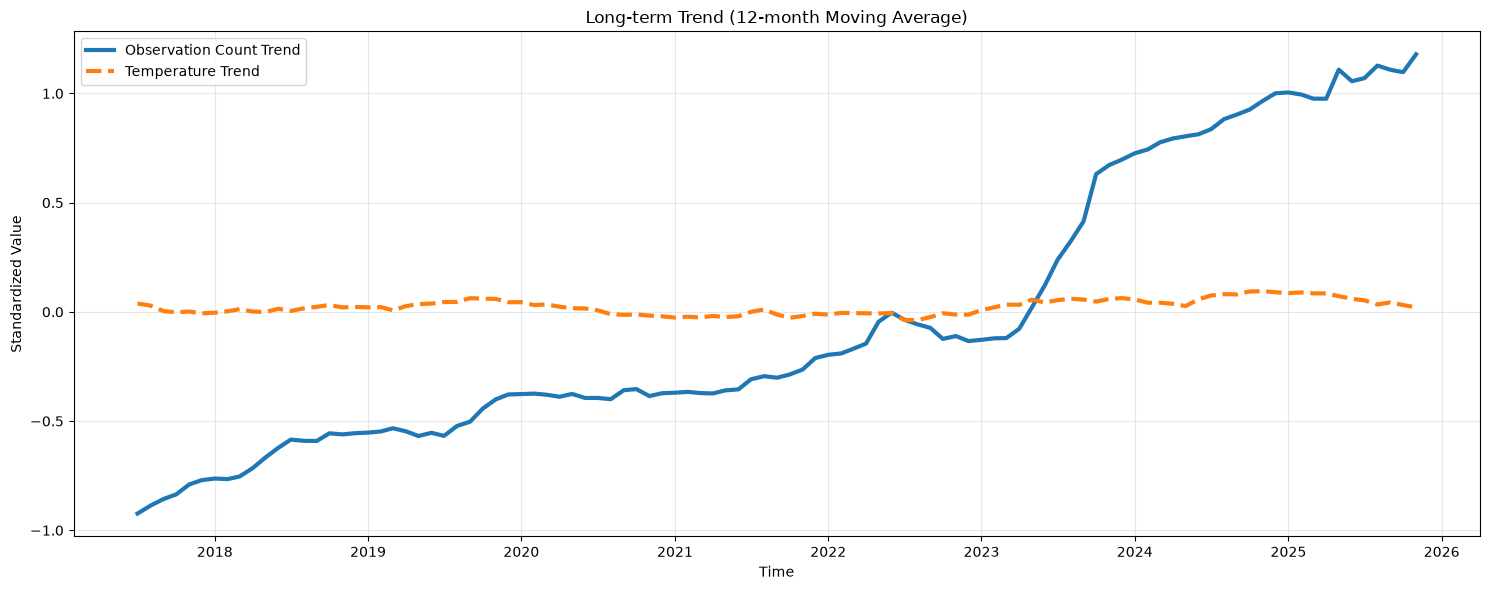

In [35]:
#figure4: overlapping figure of the 3-month trend observation count and average temperature 
plt.figure(figsize=(15,6))

plt.plot(
    merged["year_month"],
    merged["obs_12month"],
    linewidth=3,
    label="Observation Count Trend"
)

plt.plot(
    merged["year_month"],
    merged["temp_12month"],
    linewidth=3,
    linestyle="--",
    label="Temperature Trend"
)

plt.xlabel("Time")
plt.ylabel("Standardized Value")
plt.title("Long-term Trend (12-month Moving Average)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
corr = merged["monthly_observation_count"].corr(merged["tavg"])
print(f"Monthly correlation between observation count and mean temperature = {corr:.3f}")

Monthly correlation between observation count and mean temperature = -0.306


In [38]:
#setup
merged["year"] = merged["year_month"].dt.year
yearly_compare = (
    merged.groupby("year", as_index=False)
    .agg({
        "monthly_observation_count": "mean",   
        "tavg": "mean"                         
    })
)
yearly_compare["obs_scaled"] = (
    yearly_compare["monthly_observation_count"]
    - yearly_compare["monthly_observation_count"].mean()
) / yearly_compare["monthly_observation_count"].std()

yearly_compare["temp_scaled"] = (
    yearly_compare["tavg"]
    - yearly_compare["tavg"].mean()
) / yearly_compare["tavg"].std()


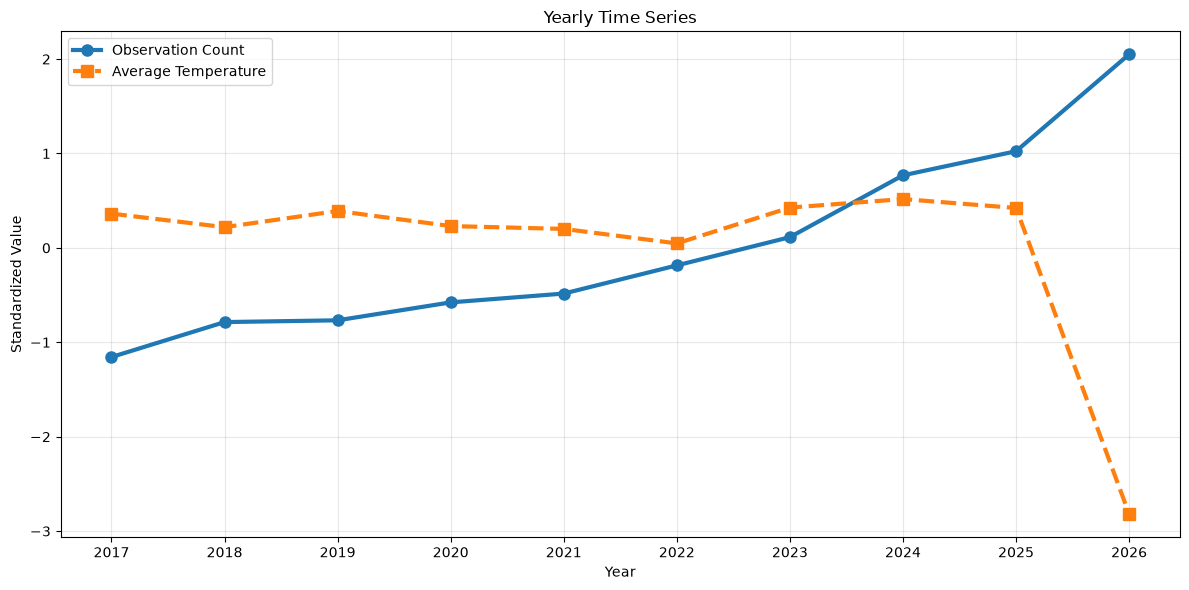

In [39]:
#figure5: yearly overlapping figure of observation count and average temperature 
plt.figure(figsize=(12,6))

plt.plot(
    yearly_compare["year"],
    yearly_compare["obs_scaled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Observation Count"
)

plt.plot(
    yearly_compare["year"],
    yearly_compare["temp_scaled"],
    marker="s",
    linewidth=3,
    linestyle="--",
    markersize=8,
    label="Average Temperature"
)

plt.xlabel("Year")
plt.ylabel("Standardized Value")

plt.title("Yearly Time Series")

plt.xticks(yearly_compare["year"])

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [41]:
corr_year = yearly_compare["monthly_observation_count"].corr(
    yearly_compare["tavg"]
)

print(f"Yearly Correlation between observation count and mean temperature = {corr_year:.3f}")

Yearly Correlation between observation count and mean temperature = -0.670


In [12]:
# New Analysis of Seasonal Bird Data
print("Seasonal Bird Data START here:\n")

# 1. File path
bird_file = "filtered_new_bird_data.csv"

weather_month_file = "monthly_weather.csv"
weather_season_file = "seasonal_weather.csv"
weather_year_file = "yearly_weather.csv"

# 2. Read bird data and weather data

bird = pd.read_csv(
    bird_file,
    low_memory=False
)

weather_month = pd.read_csv(
    weather_month_file,
    low_memory=False
)

weather_season = pd.read_csv(
    weather_season_file,
    low_memory=False
)

weather_year = pd.read_csv(
    weather_year_file,
    low_memory=False
)

# 3. Clean column names

def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace("/", "_")
    )
    return df

bird = clean_columns(bird)
weather_month = clean_columns(weather_month)
weather_season = clean_columns(weather_season)
weather_year = clean_columns(weather_year)


# 4. Convert date columns

bird["observation_date"] = pd.to_datetime(
    bird["observation_date"],
    errors="coerce"
)

bird["year"] = bird["observation_date"].dt.year
bird["month"] = bird["observation_date"].dt.month

bird = bird.dropna(
    subset=["observation_date", "common_name", "year", "month"]
)

bird["year"] = bird["year"].astype(int)
bird["month"] = bird["month"].astype(int)

# 5. Make sure weather time columns are numeric

for df in [weather_month, weather_season, weather_year]:
    if "year" in df.columns:
        df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    if "month" in df.columns:
        df["month"] = pd.to_numeric(df["month"], errors="coerce").astype("Int64")

# 6. Check data

print("Bird data shape:", bird.shape)
print("Monthly weather shape:", weather_month.shape)
print("Seasonal weather shape:", weather_season.shape)
print("Yearly weather shape:", weather_year.shape)

print("\nBird columns:")
print(bird.columns.tolist())

print("\nMonthly weather columns:")
print(weather_month.columns.tolist())

print("\nSeasonal weather columns:")
print(weather_season.columns.tolist())

print("\nYearly weather columns:")
print(weather_year.columns.tolist())

print("\nData loaded successfully.")

Seasonal Bird Data START here:

Bird data shape: (961892, 32)
Monthly weather shape: (113, 14)
Seasonal weather shape: (39, 6)
Yearly weather shape: (10, 8)

Bird columns:
['taxonomic_order', 'category', 'common_name', 'scientific_name', 'observation_count', 'country', 'state', 'county', 'county_code', 'locality', 'latitude', 'longitude', 'observation_date', 'time_observations_started', 'observation_type', 'protocol_name', 'duration_minutes', 'effort_distance_km', 'number_observers', 'all_species_reported', 'reason', 'presence', 'year', 'month', 'day', 'weekday', 'dayofyear', 'hour', 'is_weekend', 'migration_season', 'morning_peak', 'evening_peak']

Monthly weather columns:
['year', 'month', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'pres', 'gdd', 'extreme_high', 'extreme_low', 'rain_day', 'strong_wind']

Seasonal weather columns:
['year', 'season', 'tavg', 'prcp', 'gdd', 'extreme_high']

Yearly weather columns:
['year', 'tavg', 'tmin', 'tmax', 'prcp', 'gdd', 'extreme_high', 'ext

In [18]:
# PART 5: Select Target Species

species_list = [
    "Black-winged Stilt",
    "Black Drongo",
    "Yellow-browed Warbler",
    "Long-tailed Tit"
]

species_chinese = {
    "Black-winged Stilt": "黑翅长脚鹬",
    "Black Drongo": "黑卷尾",
    "Yellow-browed Warbler": "黄眉柳莺",
    "Long-tailed Tit": "长尾山雀"
}


print("Checking selected species:")
for sp in species_list:
    count = (bird["common_name"] == sp).sum()
    print(sp, ":", count)


Checking selected species:
Black-winged Stilt : 2787
Black Drongo : 3160
Yellow-browed Warbler : 6232
Long-tailed Tit : 951


In [19]:
# PART 6: Create Season Column for Bird Data

def get_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        return "Winter"

bird["season"] = bird["month"].apply(get_season)

season_order = ["Spring", "Summer", "Autumn", "Winter"]

bird["season"] = pd.Categorical(
    bird["season"],
    categories=season_order,
    ordered=True
)

bird.head()

,taxonomic_order,category,common_name,scientific_name,observation_count,country,state,county,county_code,locality,...,month,day,weekday,dayofyear,hour,is_weekend,migration_season,morning_peak,evening_peak,season
0,32288,species,Asian Rosy-Finch,Leucosticte arctoa,80.0,China,Beijing,NaN,NaN,Lingshan,...,1,5.0,0.0,5.0,-1.0,0,0,0,0,Winter
1,21391,species,Azure-winged Magpie,Cyanopica cyanus,15.0,China,Beijing,NaN,NaN,NE Beijing,...,1,4.0,6.0,4.0,-1.0,1,0,0,0,Winter
2,21391,species,Azure-winged Magpie,Cyanopica cyanus,10.0,China,Beijing,NaN,NaN,China Olympic Forest Park south,...,1,10.0,5.0,10.0,10.0,1,0,0,0,Winter
3,21391,species,Azure-winged Magpie,Cyanopica cyanus,70.0,China,Beijing,NaN,NaN,Beijing,...,1,5.0,0.0,5.0,-1.0,0,0,0,0,Winter
4,21391,species,Azure-winged Magpie,Cyanopica cyanus,4.0,China,Beijing,NaN,NaN,China Olympic Forest Park north,...,1,10.0,5.0,10.0,14.0,1,0,0,0,Winter


In [21]:
# PART 7: Monthly Species Proportion

# 每年每月所有鸟类总记录数
monthly_total = (
    bird.groupby(["year", "month"])
    .size()
    .reset_index(name="total_records")
)

# 每年每月目标物种记录数
monthly_species = (
    bird[bird["common_name"].isin(species_list)]
    .groupby(["year", "month", "common_name"])
    .size()
    .reset_index(name="species_records")
)

# Calculate Species Proportion
monthly_df = monthly_species.merge(
    monthly_total,
    on=["year", "month"],
    how="left"
)

monthly_df["species_proportion"] = (
    monthly_df["species_records"] / monthly_df["total_records"]
)

# Timeline
monthly_df["year_month"] = pd.to_datetime(
    monthly_df["year"].astype(str) + "-" + monthly_df["month"].astype(str) + "-01"
)

monthly_df.head()

,year,month,common_name,species_records,total_records,species_proportion,year_month
0,2015,4,Black-winged Stilt,5,699,0.007153,2015-04-01
1,2015,4,Yellow-browed Warbler,6,699,0.008584,2015-04-01
2,2015,5,Black Drongo,14,1669,0.008388,2015-05-01
3,2015,5,Black-winged Stilt,12,1669,0.007190,2015-05-01
4,2015,5,Yellow-browed Warbler,23,1669,0.013781,2015-05-01


In [22]:
# PART 8: Seasonal Species Proportion

# 每年每季所有鸟类总记录数
seasonal_total = (
    bird.groupby(["year", "season"])
    .size()
    .reset_index(name="total_records")
)

# 每年每季目标物种记录数
seasonal_species = (
    bird[bird["common_name"].isin(species_list)]
    .groupby(["year", "season", "common_name"])
    .size()
    .reset_index(name="species_records")
)

# 合并并计算 species proportion
seasonal_df = seasonal_species.merge(
    seasonal_total,
    on=["year", "season"],
    how="left"
)

seasonal_df["species_proportion"] = (
    seasonal_df["species_records"] / seasonal_df["total_records"]
)

seasonal_df["season"] = pd.Categorical(
    seasonal_df["season"],
    categories=season_order,
    ordered=True
)

seasonal_df.head()

,year,season,common_name,species_records,total_records,species_proportion
0,2015,Spring,Black Drongo,14,2882,0.004858
1,2015,Spring,Black-winged Stilt,17,2882,0.005899
2,2015,Spring,Yellow-browed Warbler,29,2882,0.010062
3,2015,Summer,Black Drongo,14,1106,0.012658
4,2015,Summer,Black-winged Stilt,2,1106,0.001808


In [23]:
# PART 9: Yearly Species Proportion

# 每年所有鸟类总记录数
yearly_total = (
    bird.groupby("year")
    .size()
    .reset_index(name="total_records")
)

# 每年目标物种记录数
yearly_species = (
    bird[bird["common_name"].isin(species_list)]
    .groupby(["year", "common_name"])
    .size()
    .reset_index(name="species_records")
)

# 合并并计算 species proportion
yearly_df = yearly_species.merge(
    yearly_total,
    on="year",
    how="left"
)

yearly_df["species_proportion"] = (
    yearly_df["species_records"] / yearly_df["total_records"]
)

yearly_df.head()

,year,common_name,species_records,total_records,species_proportion
0,2015,Black Drongo,34,7507,0.004529
1,2015,Black-winged Stilt,20,7507,0.002664
2,2015,Long-tailed Tit,1,7507,0.000133
3,2015,Yellow-browed Warbler,60,7507,0.007993
4,2016,Black Drongo,22,9981,0.002204


In [58]:
# ============================================================
# PART 10: Merge Bird Proportion with Weather Data
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# ------------------------------------------------------------
# 1. Clean weather data types
# ------------------------------------------------------------

weather_month["year"] = weather_month["year"].astype(int)
weather_month["month"] = weather_month["month"].astype(int)

weather_season["year"] = weather_season["year"].astype(int)
weather_year["year"] = weather_year["year"].astype(int)

weather_season["season"] = (
    weather_season["season"]
    .astype(str)
    .str.strip()
)

weather_season["season"] = (
    weather_season["season"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

seasonal_df["season"] = (
    seasonal_df["season"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

season_order = ["Spring", "Summer", "Autumn", "Winter"]

weather_season["season"] = pd.Categorical(
    weather_season["season"],
    categories=season_order,
    ordered=True
)

seasonal_df["season"] = pd.Categorical(
    seasonal_df["season"],
    categories=season_order,
    ordered=True
)

# ------------------------------------------------------------
# 2. Merge
# ------------------------------------------------------------

monthly_merged = monthly_df.merge(
    weather_month,
    on=["year", "month"],
    how="left"
)

seasonal_merged = seasonal_df.merge(
    weather_season,
    on=["year", "season"],
    how="left"
)

yearly_merged = yearly_df.merge(
    weather_year,
    on="year",
    how="left"
)

# ------------------------------------------------------------
# 3. Create seasonal time series
# 2015 Spring -> 2015 Summer -> ... -> 2026 Winter
# ------------------------------------------------------------

season_map = {
    "Spring": 1,
    "Summer": 2,
    "Autumn": 3,
    "Winter": 4
}

seasonal_merged["season_order"] = (
    seasonal_merged["season"]
    .astype(str)
    .map(season_map)
)

seasonal_merged["season_time"] = (
    seasonal_merged["year"] * 4 + seasonal_merged["season_order"]
)

seasonal_merged["season_label"] = (
    seasonal_merged["year"].astype(str)
    + " "
    + seasonal_merged["season"].astype(str)
)

print("Monthly merged:", monthly_merged.shape)
print("Seasonal merged:", seasonal_merged.shape)
print("Yearly merged:", yearly_merged.shape)

monthly_merged.head()

Monthly merged: (253, 19)
Seasonal merged: (128, 13)
Yearly merged: (47, 12)


,year,month,common_name,species_records,total_records,species_proportion,year_month,tavg,tmin,tmax,prcp,snow,wspd,pres,gdd,extreme_high,extreme_low,rain_day,strong_wind
0,2015,4,Black-winged Stilt,5,699,0.007153,2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,4,Yellow-browed Warbler,6,699,0.008584,2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,5,Black Drongo,14,1669,0.008388,2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,5,Black-winged Stilt,12,1669,0.007190,2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,5,Yellow-browed Warbler,23,1669,0.013781,2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# ============================================================
# PART 11: Define Plotting Functions
# ============================================================

fig_dir = Path.home() / "Desktop" / "bird_environment_figures"
fig_dir.mkdir(exist_ok=True)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

env_labels = {
    "tavg": "Average Temperature (°C)",
    "prcp": "Precipitation (mm)",
    "extreme_high": "Extreme High Temperature Days",
    "extreme_low": "Extreme Low Temperature Days"
}

def plot_one_species_time_series(
    data,
    species,
    time_col,
    env_col,
    title,
    filename,
    x_label,
    label_col=None
):
    sub = data[data["common_name"] == species].copy()
    sub = sub.sort_values(time_col)

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(
        sub[time_col],
        sub["species_proportion"],
        marker="o",
        linewidth=2.4,
        label="Species Proportion"
    )

    ax1.set_xlabel(x_label, fontsize=12)
    ax1.set_ylabel("Species Proportion", fontsize=12)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()

    env_data = (
        data[[time_col, env_col]]
        .drop_duplicates()
        .sort_values(time_col)
    )

    ax2.plot(
        env_data[time_col],
        env_data[env_col],
        linestyle="--",
        linewidth=2.2,
        color="black",
        label=env_labels[env_col]
    )

    ax2.set_ylabel(env_labels[env_col], fontsize=12)

    if label_col is not None:
        label_data = (
            data[[time_col, label_col]]
            .drop_duplicates()
            .sort_values(time_col)
        )

        ax1.set_xticks(label_data[time_col])

        # 如果季节太多，只显示每4个，也就是每年一个
        if len(label_data) > 20:
            display_ticks = label_data.iloc[::4]
        else:
            display_ticks = label_data

        ax1.set_xticks(display_ticks[time_col])
        ax1.set_xticklabels(
            display_ticks[label_col],
            rotation=45,
            ha="right",
            fontsize=8
        )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper left",
        fontsize=9
    )

    plt.title(title, fontsize=14)
    plt.tight_layout()

    save_path = fig_dir / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


def plot_three_time_scales_for_species(species):
    safe_name = species.replace(" ", "_").lower()

    # Monthly time series
    plot_one_species_time_series(
        data=monthly_merged,
        species=species,
        time_col="year_month",
        env_col="tavg",
        title=f"Monthly Species Proportion and Average Temperature: {species}",
        filename=f"{safe_name}_01_monthly_temperature.png",
        x_label="Month"
    )

    # Seasonal time series
    plot_one_species_time_series(
        data=seasonal_merged,
        species=species,
        time_col="season_time",
        env_col="tavg",
        title=f"Seasonal Species Proportion and Average Temperature: {species}",
        filename=f"{safe_name}_02_seasonal_temperature.png",
        x_label="Season",
        label_col="season_label"
    )

    # Yearly time series
    plot_one_species_time_series(
        data=yearly_merged,
        species=species,
        time_col="year",
        env_col="tavg",
        title=f"Yearly Species Proportion and Average Temperature: {species}",
        filename=f"{safe_name}_03_yearly_temperature.png",
        x_label="Year"
    )

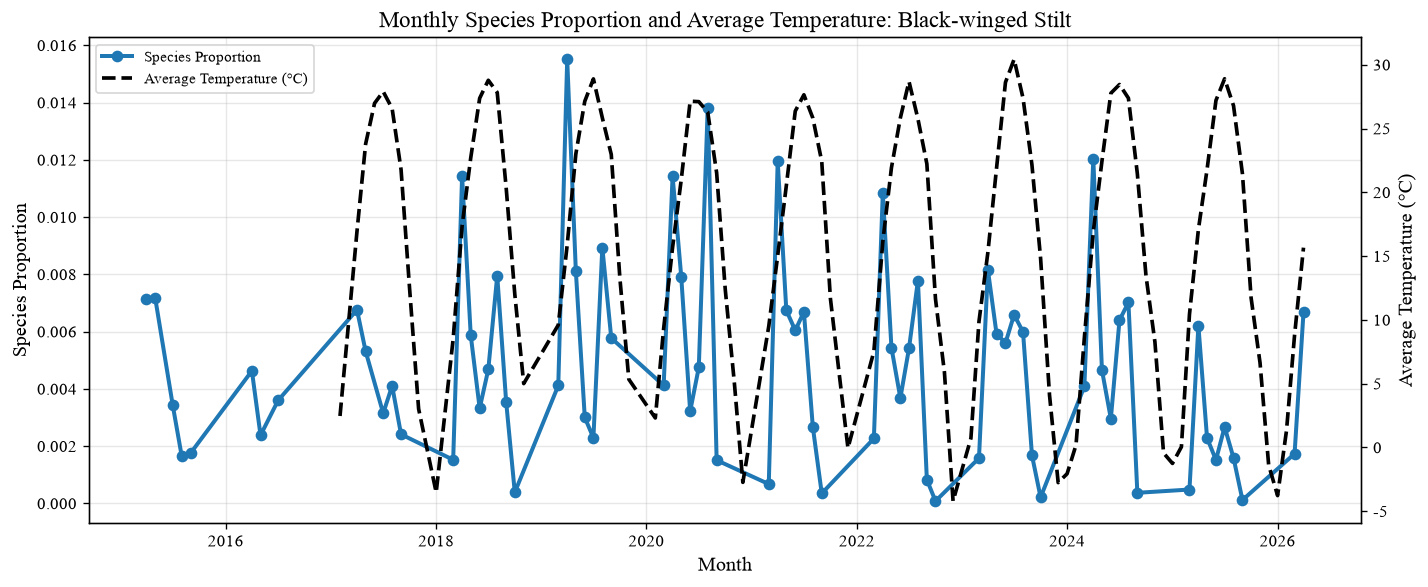

Saved: /Users/a20220927003/Desktop/bird_environment_figures/black-winged_stilt_01_monthly_temperature.png


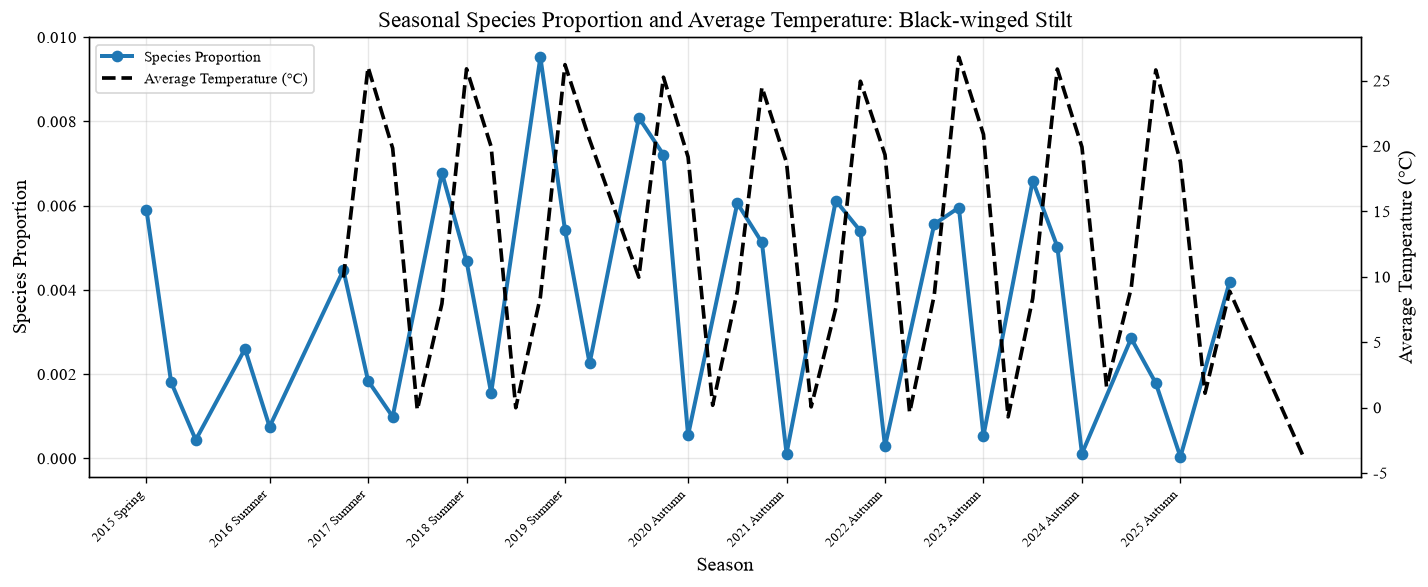

Saved: /Users/a20220927003/Desktop/bird_environment_figures/black-winged_stilt_02_seasonal_temperature.png


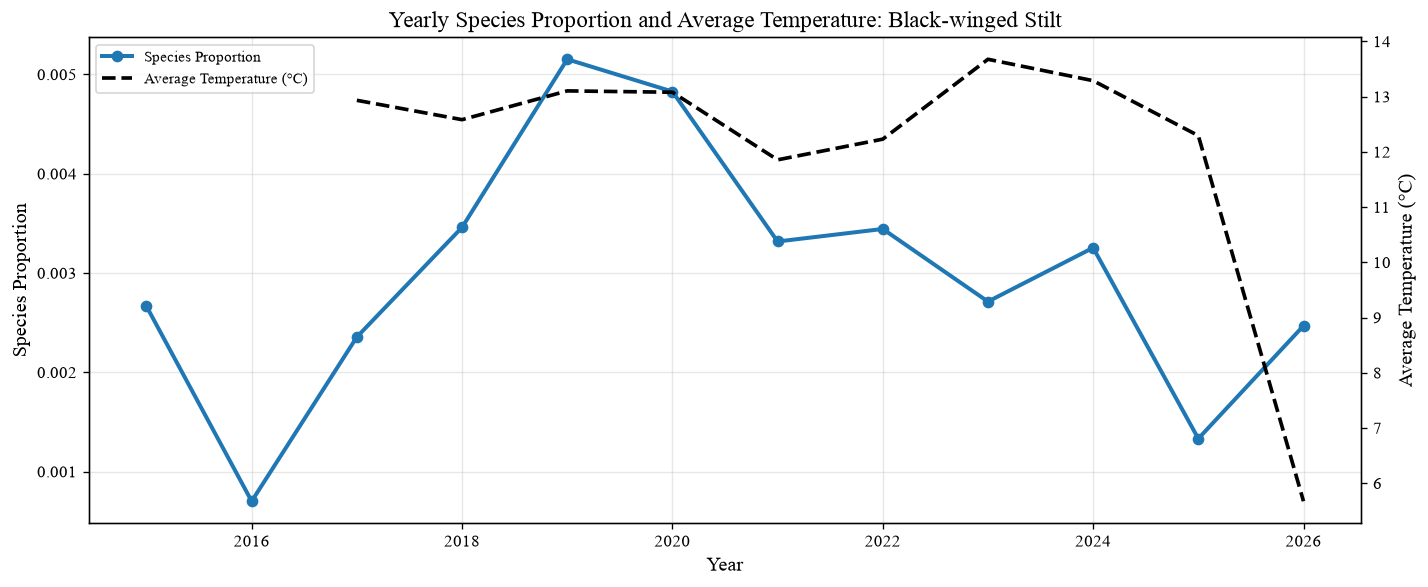

Saved: /Users/a20220927003/Desktop/bird_environment_figures/black-winged_stilt_03_yearly_temperature.png


In [40]:
# ============================================================
# PART 12A: Black-winged Stilt 黑翅长脚鹬
# ============================================================
import warnings
warnings.filterwarnings("ignore")
plot_three_time_scales_for_species("Black-winged Stilt")

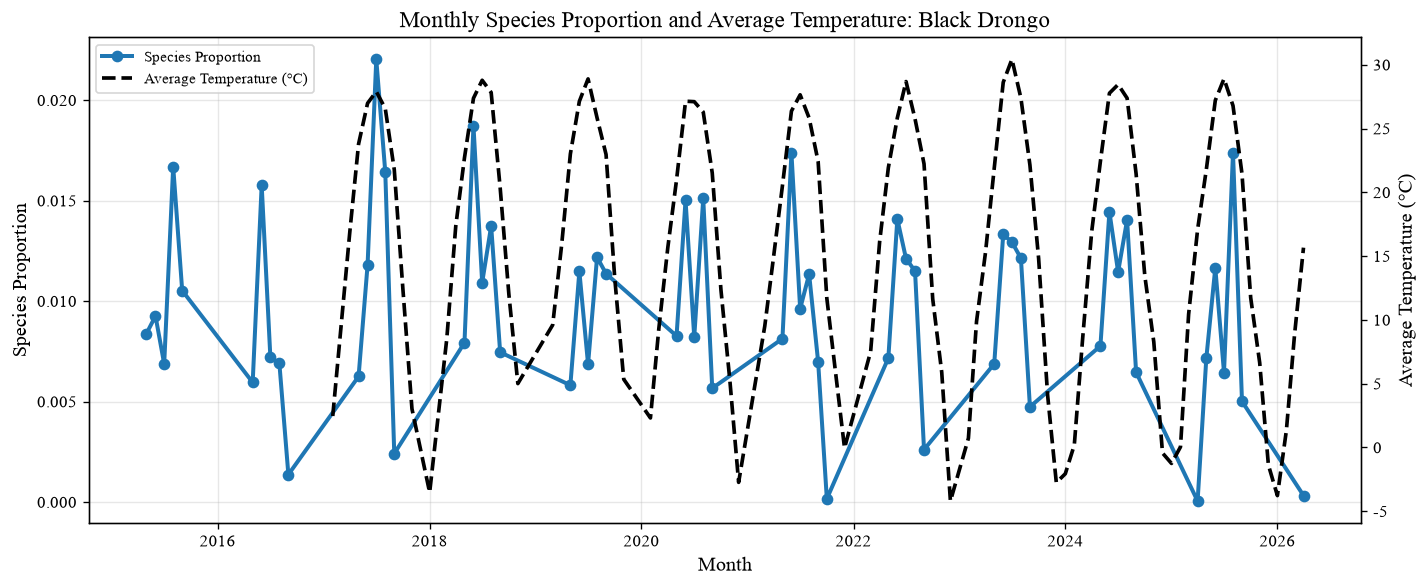

Saved: /Users/a20220927003/Desktop/bird_environment_figures/black_drongo_01_monthly_temperature.png


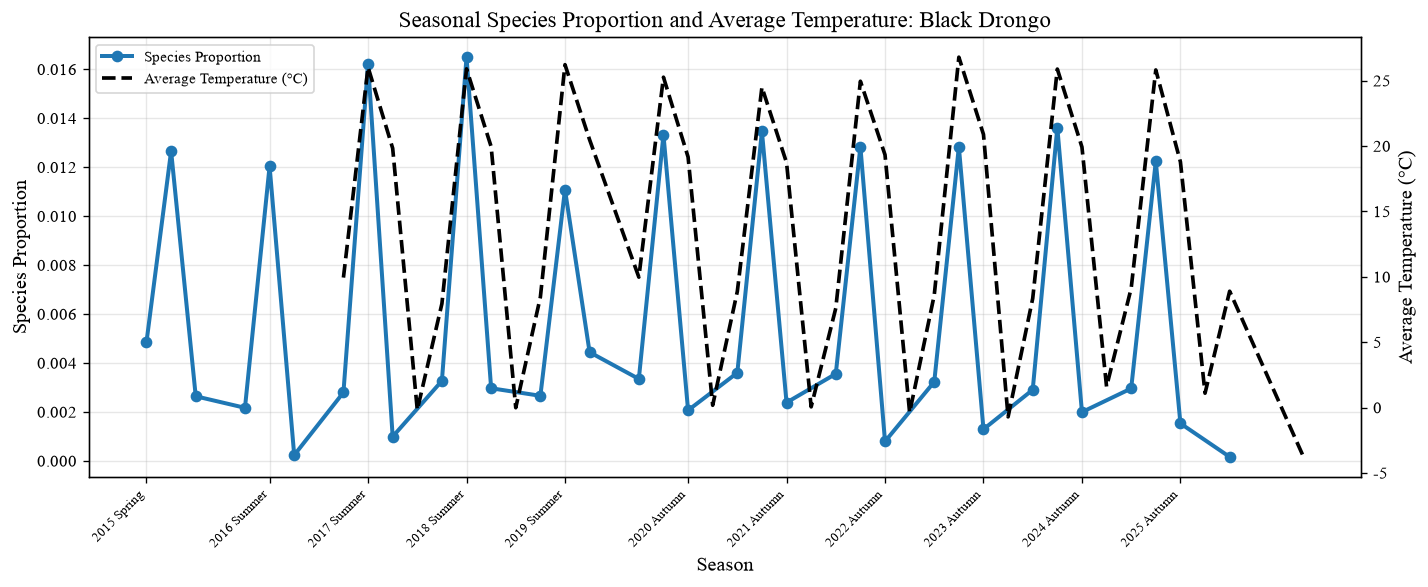

Saved: /Users/a20220927003/Desktop/bird_environment_figures/black_drongo_02_seasonal_temperature.png


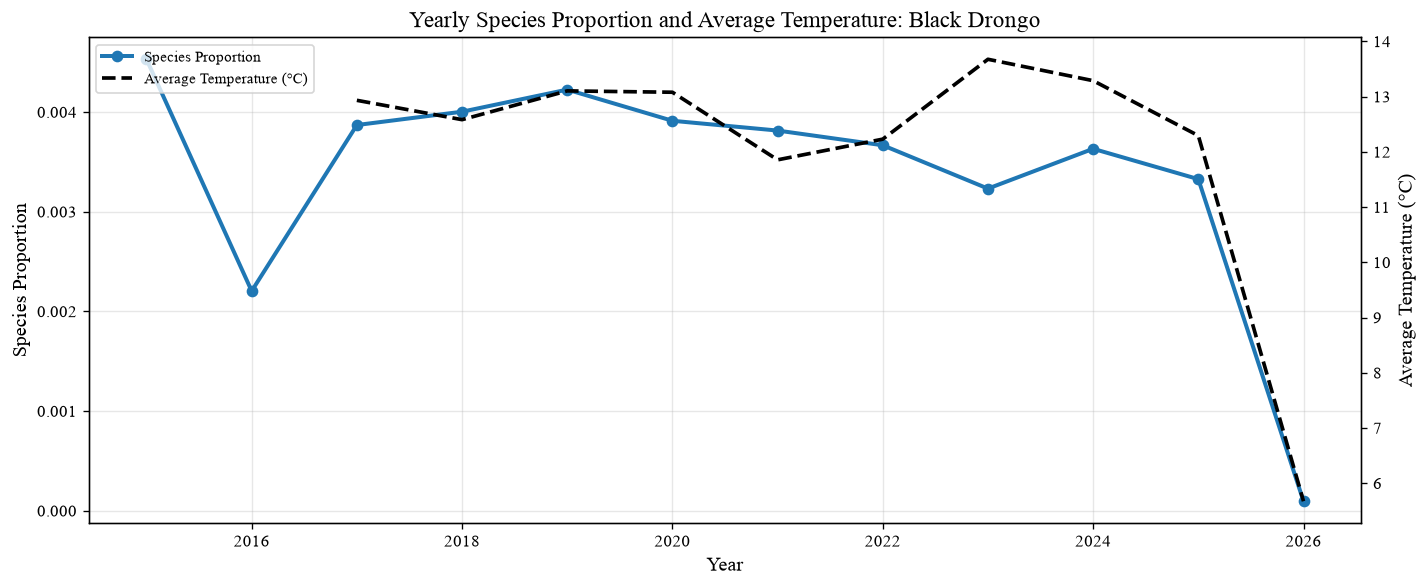

Saved: /Users/a20220927003/Desktop/bird_environment_figures/black_drongo_03_yearly_temperature.png


In [41]:
# ============================================================
# PART 12B: Black Drongo
# ============================================================

plot_three_time_scales_for_species("Black Drongo")

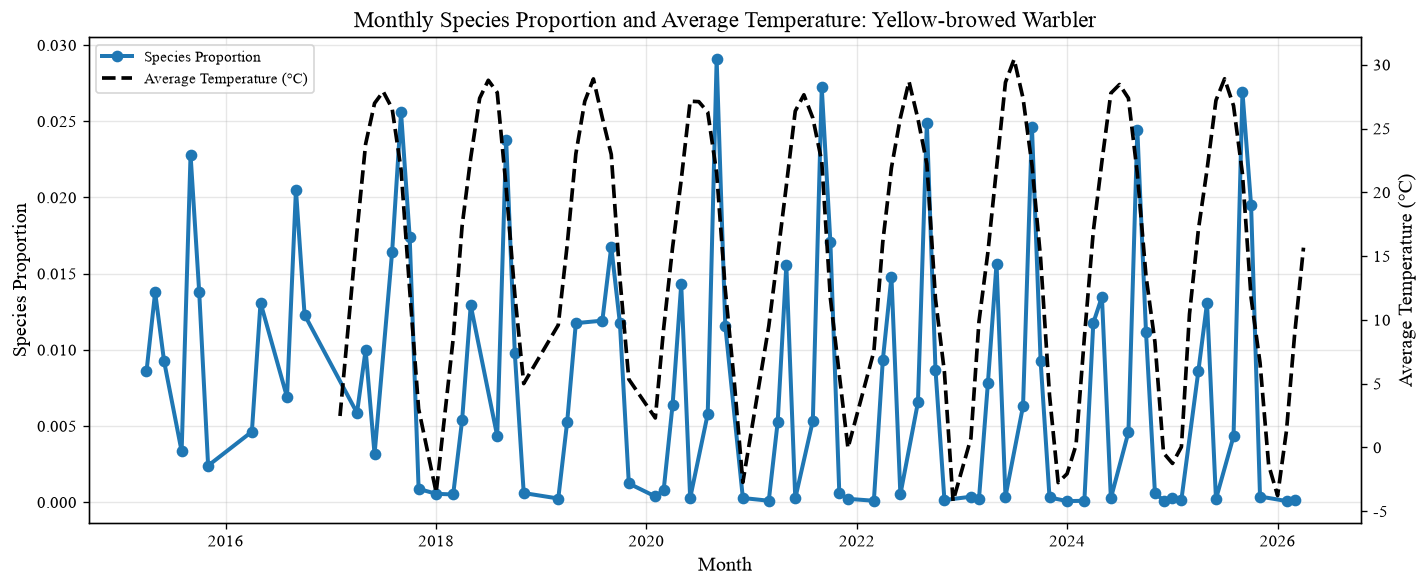

Saved: /Users/a20220927003/Desktop/bird_environment_figures/yellow-browed_warbler_01_monthly_temperature.png


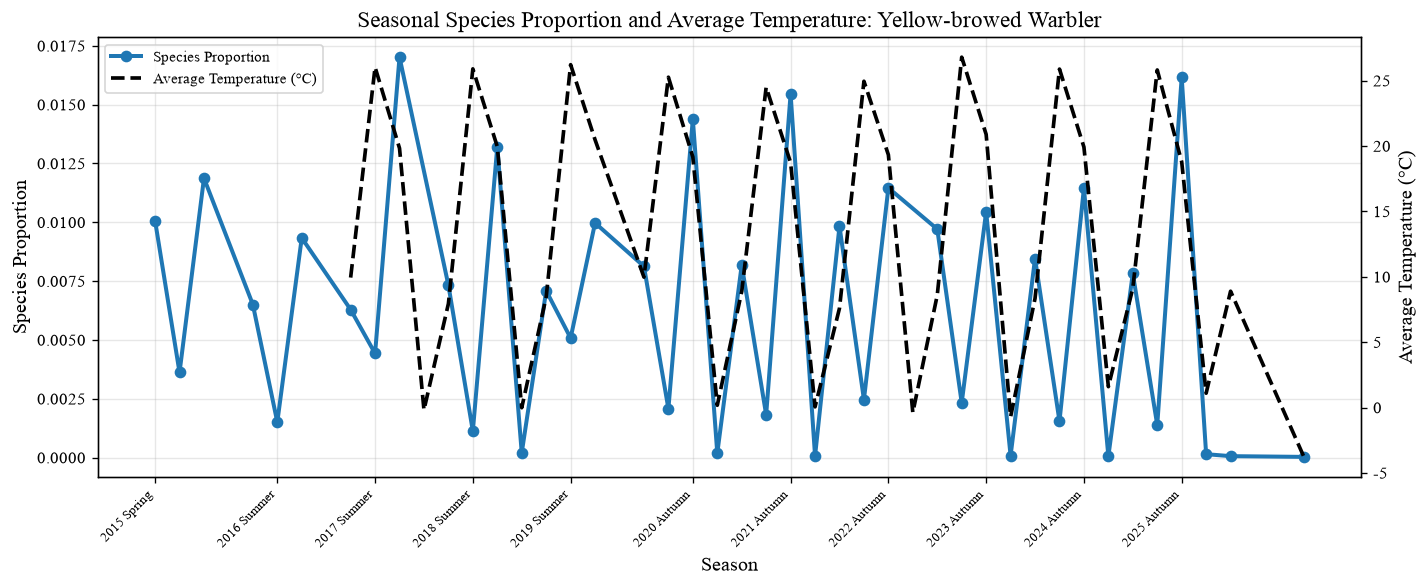

Saved: /Users/a20220927003/Desktop/bird_environment_figures/yellow-browed_warbler_02_seasonal_temperature.png


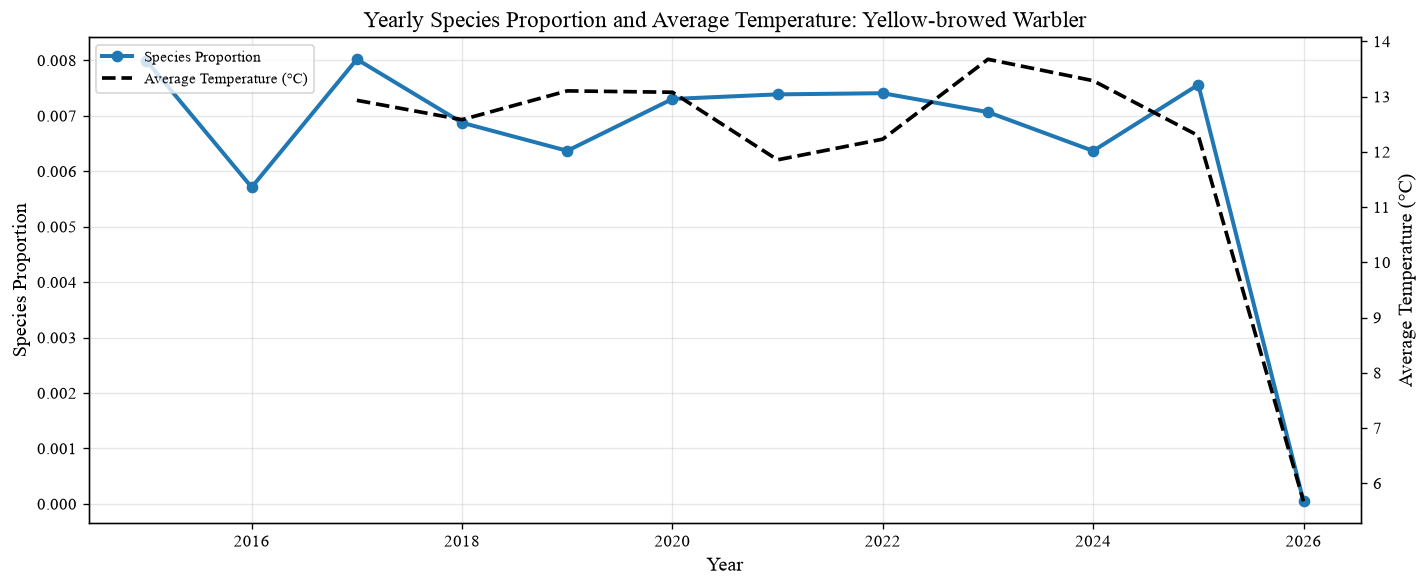

Saved: /Users/a20220927003/Desktop/bird_environment_figures/yellow-browed_warbler_03_yearly_temperature.png


In [42]:
# ============================================================
# PART 12C: Yellow-browed Warbler
# ============================================================

plot_three_time_scales_for_species("Yellow-browed Warbler")

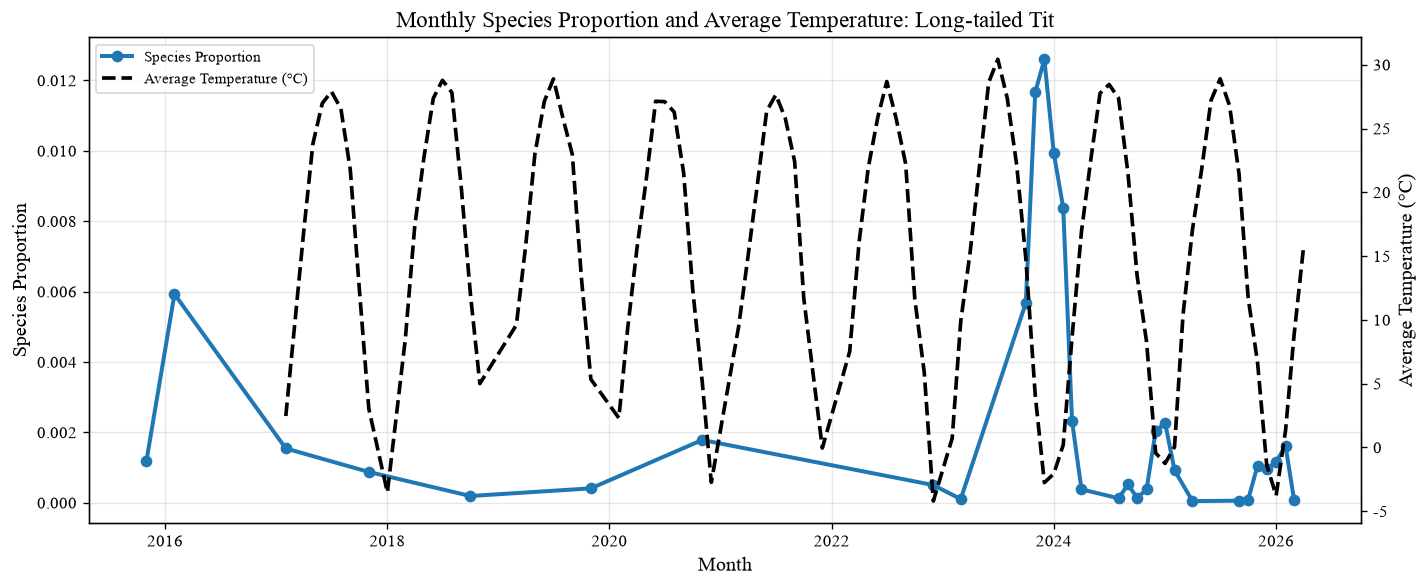

Saved: /Users/a20220927003/Desktop/bird_environment_figures/long-tailed_tit_01_monthly_temperature.png


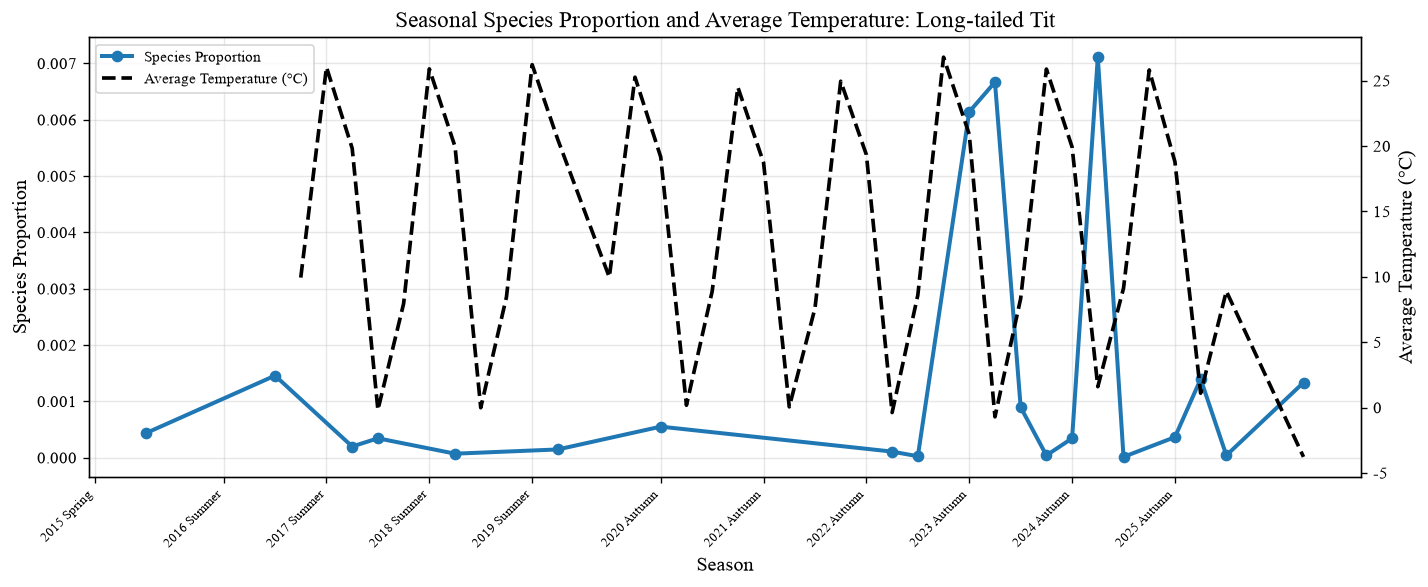

Saved: /Users/a20220927003/Desktop/bird_environment_figures/long-tailed_tit_02_seasonal_temperature.png


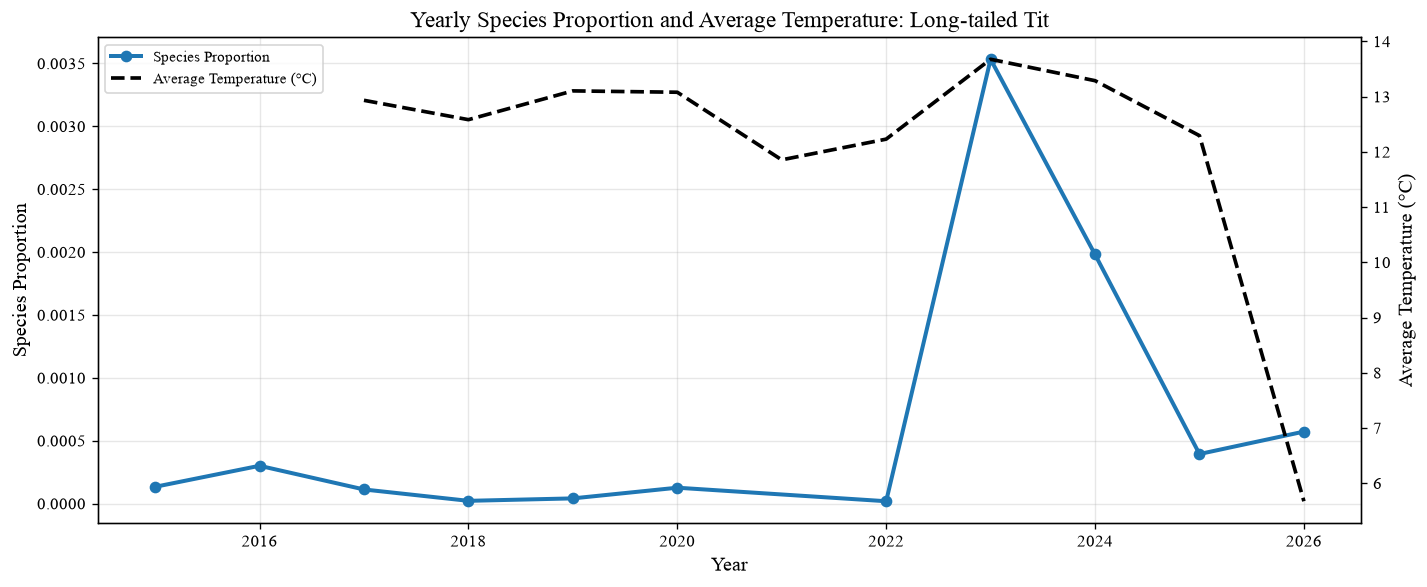

Saved: /Users/a20220927003/Desktop/bird_environment_figures/long-tailed_tit_03_yearly_temperature.png


In [43]:
# ============================================================
# PART 12D: Long-tailed Tit
# ============================================================

plot_three_time_scales_for_species("Long-tailed Tit")

In [44]:
# ============================================================
# PART 13: Correlation Calculation
# ============================================================

env_factors = ["tavg", "prcp", "extreme_high"]

correlation_all = []

for species in species_list:
    monthly_sub = monthly_merged[monthly_merged["common_name"] == species]
    seasonal_sub = seasonal_merged[seasonal_merged["common_name"] == species]
    yearly_sub = yearly_merged[yearly_merged["common_name"] == species]

    for env in env_factors:
        correlation_all.append({
            "species": species,
            "time_scale": "Month",
            "environment_factor": env,
            "correlation": monthly_sub["species_proportion"].corr(monthly_sub[env])
        })

        correlation_all.append({
            "species": species,
            "time_scale": "Season",
            "environment_factor": env,
            "correlation": seasonal_sub["species_proportion"].corr(seasonal_sub[env])
        })

        correlation_all.append({
            "species": species,
            "time_scale": "Year",
            "environment_factor": env,
            "correlation": yearly_sub["species_proportion"].corr(yearly_sub[env])
        })

correlation_all_df = pd.DataFrame(correlation_all)

correlation_all_df

,species,time_scale,environment_factor,correlation
0,Black-winged Stilt,Month,tavg,0.091996
1,Black-winged Stilt,Season,tavg,-0.349028
2,Black-winged Stilt,Year,tavg,0.280482
3,Black-winged Stilt,Month,prcp,NaN
4,Black-winged Stilt,Season,prcp,NaN
5,Black-winged Stilt,Year,prcp,NaN
6,Black-winged Stilt,Month,extreme_high,-0.018990
7,Black-winged Stilt,Season,extreme_high,-0.193880
8,Black-winged Stilt,Year,extreme_high,0.409501
9,Black Drongo,Month,tavg,0.743035


In [45]:
# ============================================================
# PART 14: Define Heatmap Function
# ============================================================

env_display_names = {
    "tavg": "Avg Temp",
    "prcp": "Precipitation",
    "extreme_high": "Extreme High"
}

def plot_species_heatmap(species):
    safe_name = species.replace(" ", "_").lower()

    sub_corr = correlation_all_df[
        correlation_all_df["species"] == species
    ]

    heatmap_data = sub_corr.pivot(
        index="time_scale",
        columns="environment_factor",
        values="correlation"
    )

    heatmap_data = heatmap_data.loc[["Month", "Season", "Year"]]
    heatmap_data = heatmap_data[env_factors]

    fig, ax = plt.subplots(figsize=(7, 4.5))

    im = ax.imshow(
        heatmap_data,
        aspect="auto",
        vmin=-1,
        vmax=1
    )

    ax.set_xticks(np.arange(len(heatmap_data.columns)))
    ax.set_yticks(np.arange(len(heatmap_data.index)))

    ax.set_xticklabels(
        [env_display_names[col] for col in heatmap_data.columns],
        fontsize=10
    )

    ax.set_yticklabels(
        heatmap_data.index,
        fontsize=10
    )

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=11
            )

    ax.set_title(
        f"Correlation Heatmap: {species}",
        fontsize=13
    )

    plt.colorbar(im, ax=ax, label="Pearson Correlation")
    plt.tight_layout()

    save_path = fig_dir / f"{safe_name}_04_correlation_heatmap.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

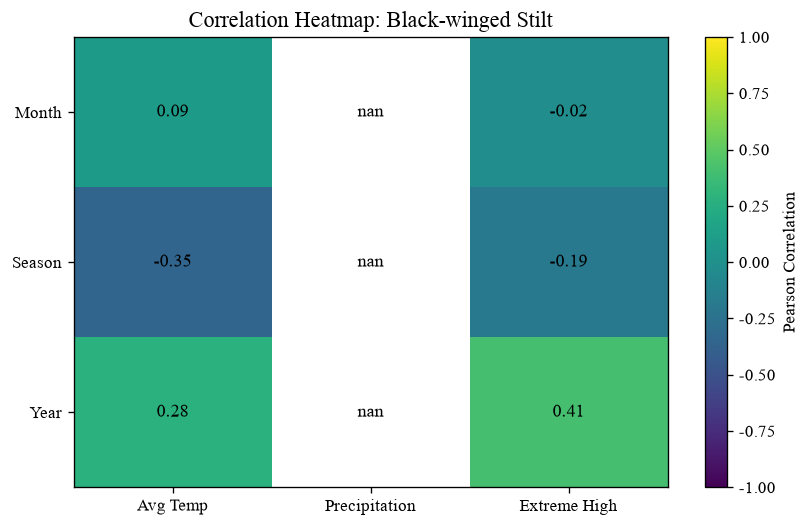

Saved: /Users/a20220927003/Desktop/bird_environment_figures/black-winged_stilt_04_correlation_heatmap.png


In [59]:
# ============================================================
# PART 14A: Heatmap - Black-winged Stilt
# ============================================================

plot_species_heatmap("Black-winged Stilt")

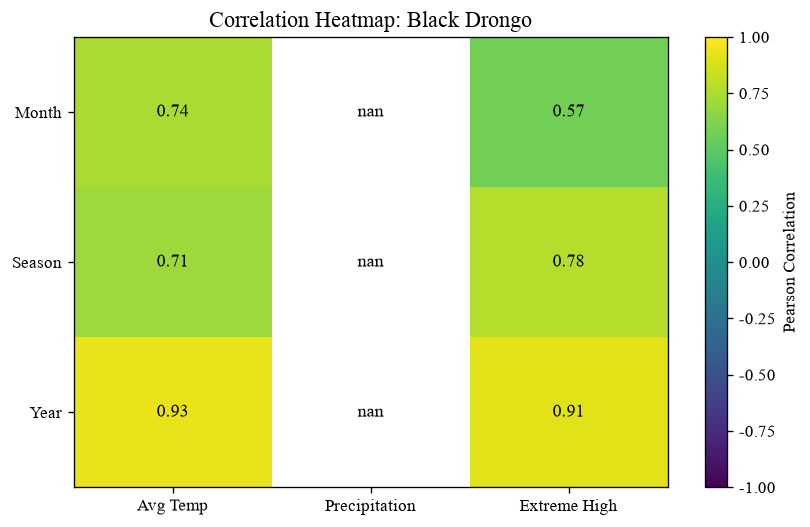

Saved: /Users/a20220927003/Desktop/bird_environment_figures/black_drongo_04_correlation_heatmap.png


In [60]:
plot_species_heatmap("Black Drongo")

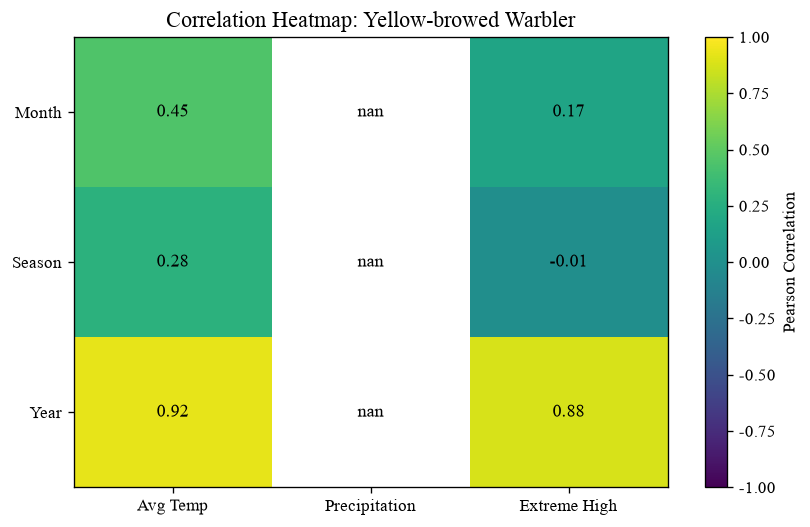

Saved: /Users/a20220927003/Desktop/bird_environment_figures/yellow-browed_warbler_04_correlation_heatmap.png


In [62]:
plot_species_heatmap("Yellow-browed Warbler")

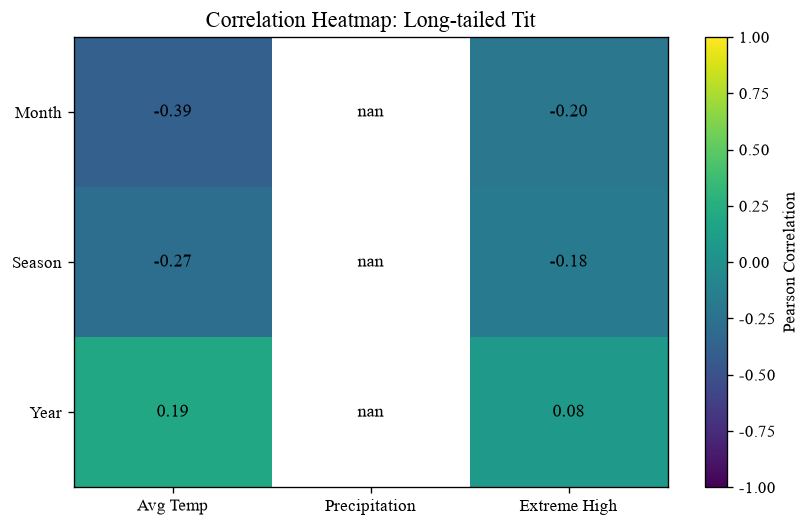

Saved: /Users/a20220927003/Desktop/bird_environment_figures/long-tailed_tit_04_correlation_heatmap.png


In [63]:
plot_species_heatmap("Long-tailed Tit")